# EDA

In [ ]:
import pandas as pd
import numpy as np


In [4]:
train= pd.read_csv('emotions_train.csv')
test= pd.read_csv('emotions_test.csv')

In [ ]:
train.head()

,Text,Emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [7]:
test.head()

,tweet_id,sentiment,author,content
0,1956967341,empty,xoshayzers,@tiffanylue i know i was listenin to bad habi...
1,1956967666,sadness,wannamama,Layin n bed with a headache ughhhh...waitin o...
2,1956967696,sadness,coolfunky,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,czareaquino,wants to hang out with friends SOON!
4,1956968416,neutral,xkilljoyx,@dannycastillo We want to trade with someone w...


In [8]:
print("dimension :",train.shape)
train.info()

dimension : (21459, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21459 entries, 0 to 21458
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Text     21459 non-null  object
 1   Emotion  21459 non-null  object
dtypes: object(2)
memory usage: 335.4+ KB


In [9]:
print("dimension :",test.shape)
test.info()

dimension : (40000, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tweet_id   40000 non-null  int64 
 1   sentiment  40000 non-null  object
 2   author     40000 non-null  object
 3   content    40000 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.2+ MB


In [10]:
train.describe()

,Text,Emotion
count,21459,21459
unique,21405,6
top,i feel more adventurous willing to take risks ...,joy
freq,2,7029


Le sentiment le plus présent dans les données d'entrainement est la joie 'joy'

Compte des sentimets dans les données d'entrainement et de test

In [26]:
sentiment_train = train['Emotion'].value_counts()
print( sentiment_train)

Emotion
joy         7029
sadness     6265
anger       2993
fear        2652
love        1641
surprise     879
Name: count, dtype: int64


In [28]:
sentiment_test = test['sentiment'].value_counts()
print( sentiment_test)

sentiment
neutral       8638
worry         8459
joy           5209
sadness       5165
love          3842
surprise      2187
fun           1776
relief        1526
hate          1323
empty          827
enthusiasm     759
boredom        179
anger          110
Name: count, dtype: int64


Les données d'entrainement présentent plus de sentiments neutre 'neutral'

Visualisation des sentiments

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\Dorène\AppData\Local\Temp\ipykernel_6052\3907420237.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_train.index, y=sentiment_train.values, palette="viridis")


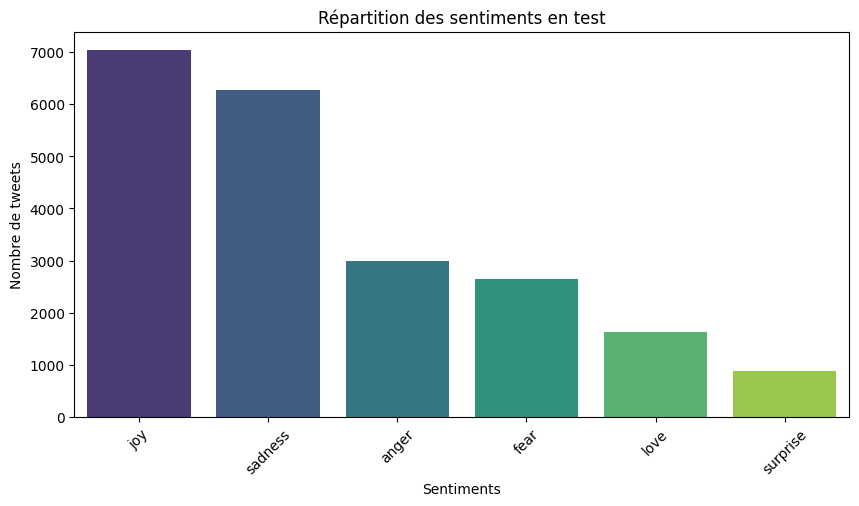

In [32]:
plt.figure(figsize=(10,5))
sns.barplot(x=sentiment_train.index, y=sentiment_train.values, palette="viridis")
plt.title("Répartition des sentiments en test")
plt.ylabel("Nombre de tweets")
plt.xlabel("Sentiments")
plt.xticks(rotation=45)
plt.show()

C:\Users\Dorène\AppData\Local\Temp\ipykernel_6052\545271318.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_test.index, y=sentiment_test.values, palette="viridis")


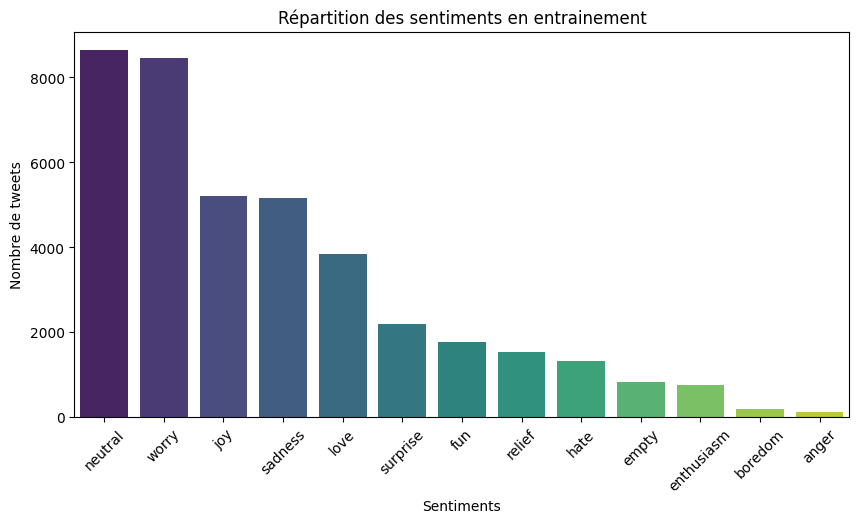

In [31]:
plt.figure(figsize=(10,5))
sns.barplot(x=sentiment_test.index, y=sentiment_test.values, palette="viridis")
plt.title("Répartition des sentiments en entrainement")
plt.ylabel("Nombre de tweets")
plt.xlabel("Sentiments")
plt.xticks(rotation=45)
plt.show()

vérification des données manquantes

In [ ]:
train.isnull().mean() * 100


Text       0.0
Emotion    0.0
dtype: float64

In [25]:
test.isnull().mean() * 100

tweet_id     0.0
sentiment    0.0
author       0.0
content      0.0
dtype: float64

les données d'entrainemnt et de tes ne présentes aucunes valeurs manquantes

On peut aussi visualiser un nuage de point par émotion pour voir les mots qui dominent

In [34]:
from wordcloud import WordCloud

On analyse les calsses uniques

In [43]:
unique_classes = train['Emotion'].unique()
num_classes = len(unique_classes)
unique_classes, num_classes


(array(['sadness', 'anger', 'love', 'surprise', 'fear', 'joy'],
       dtype=object),
 6)

In [44]:
unique_classes = test['sentiment'].unique()
num_classes = len(unique_classes)
unique_classes, num_classes


(array(['empty', 'sadness', 'enthusiasm', 'neutral', 'worry', 'surprise',
        'love', 'fun', 'hate', 'joy', 'boredom', 'relief', 'anger'],
       dtype=object),
 13)

Le top des auteurs par tweets

In [ ]:
top_authors = test['author'].value_counts().head(10)
top_authors


author
MissxMarisa       23
ChineseLearn      22
MiDesfileNegro    19
erkagarcia        19
lost_dog          18
tsarnick          17
KimmiMcfly        15
linnetwoods       15
Quimo             14
Dogbook           14
Name: count, dtype: int64